# K-Means Clustering

This notebook fits a K-Means clustering model to the customer-level feature matrix. It applies log transformation and z-score standardization, uses elbow and silhouette analysis to select the optimal number of clusters, and profiles the resulting segments.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

try:
    from kneed import KneeLocator
except:
    ! pip install kneed
    from kneed import KneeLocator

## Helper Classes

In [2]:
class LogTransform:
    """Log1p transform to reduce right-skew in features."""
    def __init__(self, list_cols):
        self.list_cols = list_cols

    def fit(self, X):
        print(f'Log transform: {len(self.list_cols)} columns')
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.list_cols:
            X[col] = np.log1p(X[col])
        return X


class ScaleFeatures:
    """Z-score standardization."""
    def __init__(self, list_cols):
        self.list_cols = list_cols
        self.scaler = StandardScaler()

    def fit(self, X):
        print(f'Scaling: {len(self.list_cols)} columns')
        self.scaler.fit(X[self.list_cols])
        return self

    def transform(self, X):
        X = X.copy()
        X[self.list_cols] = self.scaler.transform(X[self.list_cols])
        return X


class PreprocessingModel:
    """Composable preprocessing pipeline."""
    def __init__(self, list_cls_transformers):
        self.list_cls_transformers = list_cls_transformers

    def transform(self, X):
        for cls_transformer in self.list_cls_transformers:
            X = cls_transformer.transform(X)
        return X

## Constants

In [3]:
str_bucket = 'cluster-analysis-demo'
print(f'Bucket: {str_bucket}')

str_task = '03_clustering'
print(f'Task: {str_task}')

str_dirname_output = './output'

# data uri
str_uri = f's3://{str_bucket}/02_preprocessing/df_customers.parquet'

# features to use for clustering
list_features = [
    'recency', 'frequency', 'monetary', 'avg_order_value',
    'avg_items_per_order', 'unique_products', 'avg_unit_price', 'tenure_days',
]

# features to log transform (right-skewed)
list_cols_log = [
    'frequency', 'monetary', 'avg_order_value',
    'avg_items_per_order', 'unique_products', 'avg_unit_price',
]

Bucket: cluster-analysis-demo
Task: 03_clustering


## Output Directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

## Import Data

In [5]:
df = pd.read_parquet(str_uri)
print(f'Customers: {df.shape[0]:,}')
df.head()

Customers: 4,312


,customer_id,recency,frequency,monetary,avg_order_value,avg_items_per_order,unique_products,avg_unit_price,tenure_days
0,12346.0,165,11,372.86,33.896364,6.363636,26,6.253333,196
1,12347.0,3,2,1323.32,661.660000,414.000000,70,2.295070,37
2,12348.0,74,1,222.16,222.160000,373.000000,20,0.719500,0
3,12349.0,43,3,2671.14,890.380000,331.000000,90,8.581765,181
4,12351.0,11,1,300.93,300.930000,261.000000,21,2.355238,0


## Build Preprocessing Pipeline

Log-transform right-skewed features, then z-score standardize all features. K-Means is distance-based, so features must be on comparable scales.

In [6]:
# extract feature matrix
X = df[list_features].copy()

# log transform
cls_log = LogTransform(list_cols=list_cols_log)
cls_log.fit(X)
X = cls_log.transform(X)

# z-score standardization
cls_scale = ScaleFeatures(list_cols=list_features)
cls_scale.fit(X)
X = cls_scale.transform(X)

# assemble pipeline
cls_model_preprocessing = PreprocessingModel(
    list_cls_transformers=[cls_log, cls_scale],
)

X.head()

Log transform: 6 columns
Scaling: 8 columns


,recency,frequency,monetary,avg_order_value,avg_items_per_order,unique_products,avg_unit_price,tenure_days
0,0.762299,1.613017,-0.540688,-2.814176,-3.117182,-0.254093,1.076542,0.466837
1,-0.910402,-0.394693,0.447651,1.157360,1.081330,0.591067,-0.467222,-0.730346
2,-0.177305,-0.981910,-0.943904,-0.310945,0.973004,-0.473778,-1.739735,-1.008936
3,-0.497389,0.021945,0.996204,1.557374,0.848955,0.808012,1.621240,0.353895
4,-0.827799,-0.981910,-0.707671,0.096891,0.602369,-0.433113,-0.431819,-1.008936


## Save Preprocessing Pipeline

In [7]:
str_filename = 'cls_model_preprocessing.joblib'
str_local_path = f'{str_dirname_output}/{str_filename}'
joblib.dump(cls_model_preprocessing, str_local_path)
print(f'Saved preprocessing pipeline to {str_local_path}')

Saved preprocessing pipeline to ./output/cls_model_preprocessing.joblib


## Elbow Method

Fit K-Means for a range of K values and plot inertia (within-cluster sum of squares) to identify the optimal number of clusters.

In [8]:
list_k = list(range(2, 11))
list_inertia = []
list_silhouette = []

for k in tqdm(list_k):
    cls_km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cls_km.fit(X)
    list_inertia.append(cls_km.inertia_)
    flt_silhouette = silhouette_score(X, cls_km.labels_)
    list_silhouette.append(flt_silhouette)
    print(f'K={k}: Inertia={cls_km.inertia_:,.0f}, Silhouette={flt_silhouette:.4f}')

 11%|█         | 1/9 [00:00<00:04,  1.80it/s]

K=2: Inertia=23,142, Silhouette=0.3021


 22%|██▏       | 2/9 [00:01<00:03,  2.02it/s]

K=3: Inertia=19,674, Silhouette=0.2354


 33%|███▎      | 3/9 [00:01<00:03,  1.94it/s]

...

K=8: Inertia=11,873, Silhouette=0.1931


 89%|████████▉ | 8/9 [00:04<00:00,  1.55it/s]

K=9: Inertia=11,325, Silhouette=0.1854


100%|██████████| 9/9 [00:05<00:00,  1.68it/s]

K=10: Inertia=10,826, Silhouette=0.1788


## Elbow and Silhouette Plots

Elbow detected at K=5


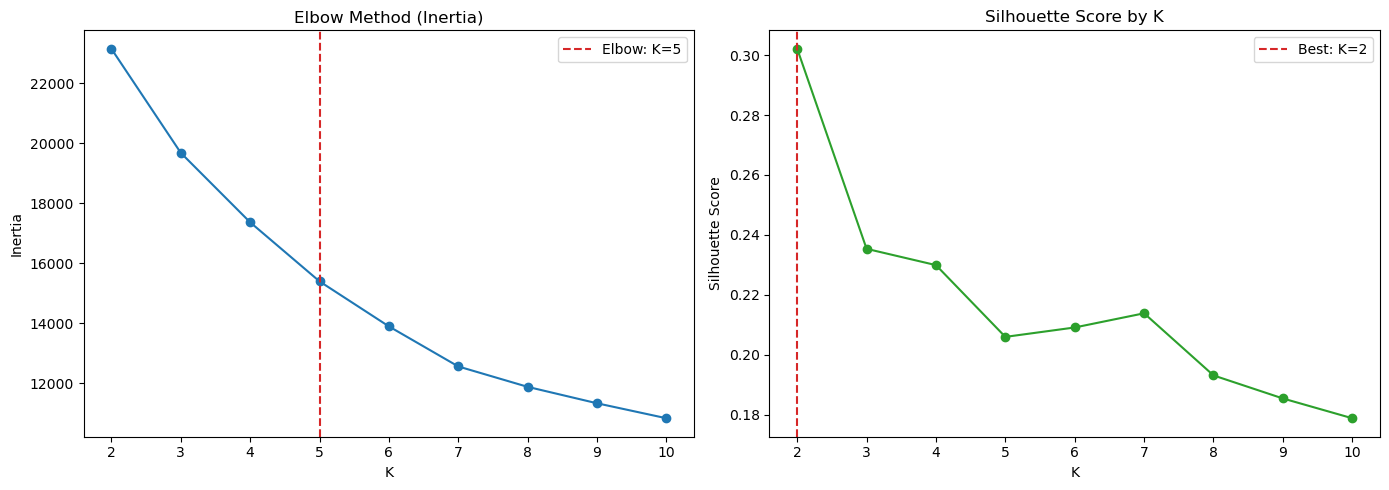

In [9]:
# detect elbow
kl = KneeLocator(list_k, list_inertia, curve='convex', direction='decreasing')
int_k_elbow = kl.elbow
print(f'Elbow detected at K={int_k_elbow}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# elbow plot
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].plot(list_k, list_inertia, marker='o', color='tab:blue')
if int_k_elbow:
    axes[0].axvline(x=int_k_elbow, color='tab:red', linestyle='--', label=f'Elbow: K={int_k_elbow}')
    axes[0].legend()
axes[0].set_xticks(list_k)

# silhouette plot
axes[1].set_title('Silhouette Score by K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].plot(list_k, list_silhouette, marker='o', color='tab:green')
int_k_best_sil = list_k[np.argmax(list_silhouette)]
axes[1].axvline(x=int_k_best_sil, color='tab:red', linestyle='--', label=f'Best: K={int_k_best_sil}')
axes[1].legend()
axes[1].set_xticks(list_k)

plt.tight_layout()
plt.savefig(f'{str_dirname_output}/elbow_silhouette.png', bbox_inches='tight', dpi=150)
plt.show()

## Select Optimal K and Fit Final Model

In [10]:
# use the elbow K as optimal
int_k_optimal = int_k_elbow
print(f'Optimal K: {int_k_optimal}')

# fit final model
cls_kmeans = KMeans(n_clusters=int_k_optimal, random_state=42, n_init=10)
cls_kmeans.fit(X)

# assign clusters
df['cluster'] = cls_kmeans.labels_

flt_silhouette_final = silhouette_score(X, cls_kmeans.labels_)
print(f'Final Silhouette Score: {flt_silhouette_final:.4f}')
print(f'Final Inertia: {cls_kmeans.inertia_:,.0f}')
print(f'\nCluster Sizes:')
print(df['cluster'].value_counts().sort_index())

Optimal K: 5
Final Silhouette Score: 0.2060
Final Inertia: 15,389

Cluster Sizes:
cluster
0    1078
1    1019
2     963
3      44
4    1208
Name: count, dtype: int64


## Silhouette Analysis by Cluster

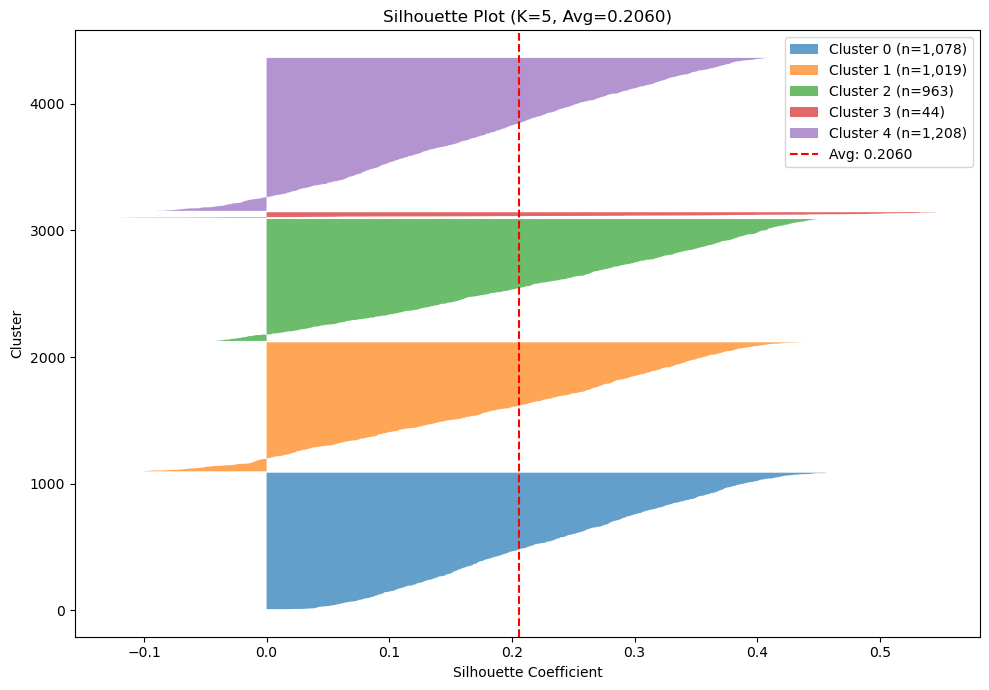

In [11]:
arr_silhouette_vals = silhouette_samples(X, cls_kmeans.labels_)

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_title(f'Silhouette Plot (K={int_k_optimal}, Avg={flt_silhouette_final:.4f})')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')

y_lower = 10
for i in range(int_k_optimal):
    arr_cluster_sil = arr_silhouette_vals[cls_kmeans.labels_ == i]
    arr_cluster_sil.sort()
    int_size = arr_cluster_sil.shape[0]
    y_upper = y_lower + int_size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, arr_cluster_sil, alpha=0.7,
                      label=f'Cluster {i} (n={int_size:,})')
    y_lower = y_upper + 10

ax.axvline(x=flt_silhouette_final, color='red', linestyle='--', label=f'Avg: {flt_silhouette_final:.4f}')
ax.legend(loc='best')
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/silhouette_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

## Cluster Centroids (Original Scale)

In [12]:
df_centroids = df.groupby(by='cluster', as_index=False)[list_features].mean()
df_centroids.to_csv(f'{str_dirname_output}/cluster_centroids.csv', index=False)
print(f'Saved cluster centroids to {str_dirname_output}/cluster_centroids.csv')
df_centroids

Saved cluster centroids to ./output/cluster_centroids.csv


,cluster,recency,frequency,monetary,avg_order_value,avg_items_per_order,unique_products,avg_unit_price,tenure_days
0,0,45.661410,4.215213,933.102023,234.053983,125.430492,58.688312,3.409288,213.563080
1,1,174.994112,1.367026,201.459205,157.042444,83.917642,14.759568,3.558020,19.070658
2,2,29.904465,11.593977,6733.793405,561.335625,392.831026,152.893043,3.295413,289.098650
3,3,183.659091,1.636364,1593.365455,761.087551,27.271843,2.340909,644.161148,20.590909
4,4,106.549669,1.687914,882.517578,533.887968,416.041600,40.394868,3.068346,40.430464


## Cluster Centroid Heatmap (Standardized)

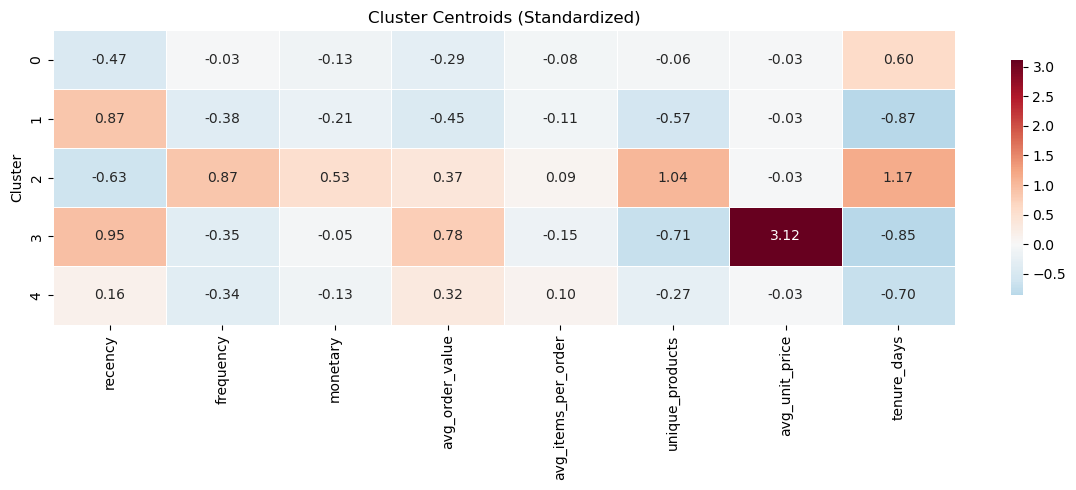

In [13]:
# standardize centroids for visual comparison across features
df_centroids_std = df_centroids.copy()
for col in list_features:
    flt_mean = df[col].mean()
    flt_std = df[col].std()
    df_centroids_std[col] = (df_centroids_std[col] - flt_mean) / flt_std

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title('Cluster Centroids (Standardized)')
sns.heatmap(
    df_centroids_std[list_features].set_index(df_centroids_std['cluster']),
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8},
)
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/centroid_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

## Feature Distributions by Cluster

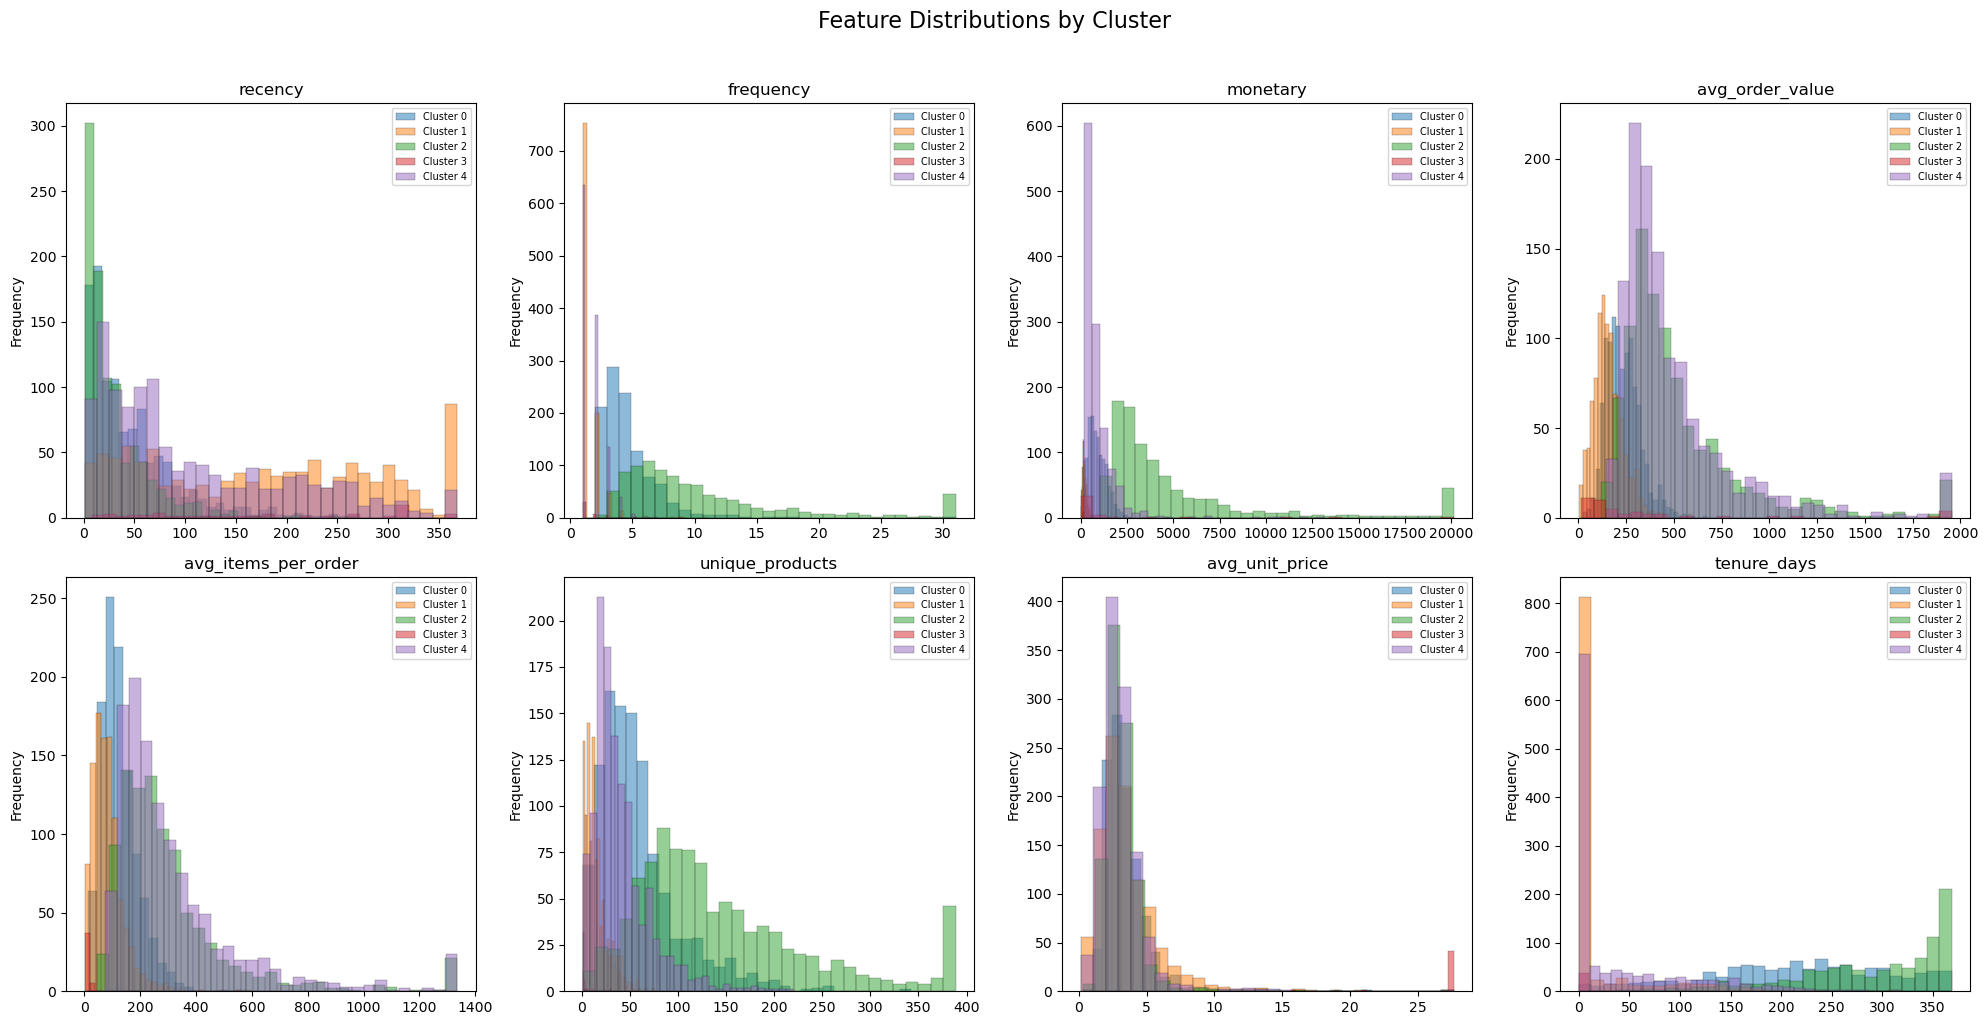

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Feature Distributions by Cluster', fontsize=16, y=1.02)

for idx, col in enumerate(list_features):
    row, col_idx = divmod(idx, 4)
    ax = axes[row][col_idx]
    p99 = df[col].quantile(0.99)
    for cluster_id in sorted(df['cluster'].unique()):
        ser_clipped = df.loc[df['cluster'] == cluster_id, col].clip(upper=p99)
        ax.hist(ser_clipped, bins=30, alpha=0.5, label=f'Cluster {cluster_id}', edgecolor='black', linewidth=0.3)
    ax.set_title(col)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(f'{str_dirname_output}/distributions_by_cluster.png', bbox_inches='tight', dpi=150)
plt.show()

## Cluster Size Distribution

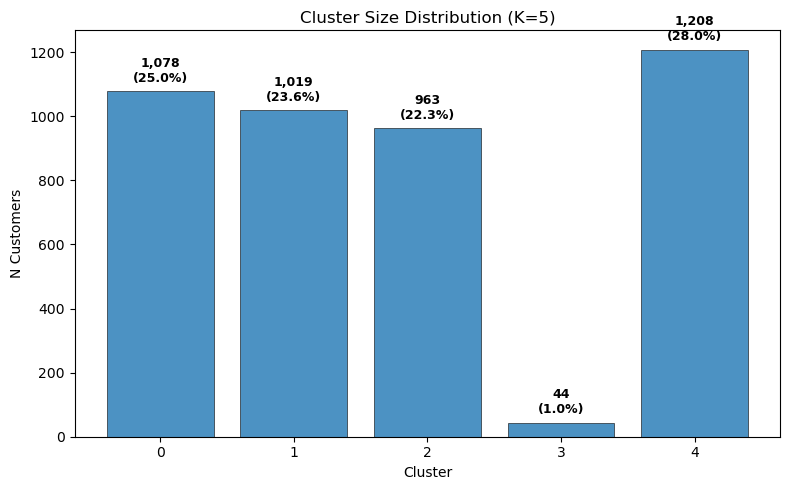

In [15]:
ser_counts = df['cluster'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(ser_counts.index, ser_counts.values, color='tab:blue', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.set_title(f'Cluster Size Distribution (K={int_k_optimal})')
ax.set_xlabel('Cluster')
ax.set_ylabel('N Customers')
ax.set_xticks(ser_counts.index)
for bar, val in zip(bars, ser_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f'{val:,}\n({val / len(df):.1%})', ha='center', va='bottom', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig(f'{str_dirname_output}/cluster_sizes.png', bbox_inches='tight', dpi=150)
plt.show()

## Save K-Means Model

In [16]:
str_filename = 'cls_model_inference.joblib'
str_local_path = f'{str_dirname_output}/{str_filename}'
joblib.dump(cls_kmeans, str_local_path)
print(f'Saved K-Means model to {str_local_path}')

Saved K-Means model to ./output/cls_model_inference.joblib


## Save Tuning Results

In [17]:
df_tuning = pd.DataFrame({
    'k': list_k,
    'inertia': list_inertia,
    'silhouette': list_silhouette,
})
df_tuning['selected'] = df_tuning['k'] == int_k_optimal
df_tuning.to_csv(f'{str_dirname_output}/df_tuning.csv', index=False)
print(f'Saved tuning results to {str_dirname_output}/df_tuning.csv')
df_tuning

Saved tuning results to ./output/df_tuning.csv


,k,inertia,silhouette,selected
0,2,23142.285619,0.302116,False
1,3,19674.445719,0.235351,False
2,4,17358.370134,0.229912,False
3,5,15389.063603,0.205961,True
4,6,13887.873890,0.209102,False
5,7,12552.480886,0.213836,False
6,8,11872.547621,0.193101,False
7,9,11324.779899,0.185409,False
8,10,10825.905371,0.178803,False


## Save Cluster Assignments to S3

In [18]:
str_uri_export = f's3://{str_bucket}/{str_task}/df_clustered.parquet'
df.to_parquet(str_uri_export, index=False)
print(f'Saved {df.shape[0]:,} customers with cluster assignments to {str_uri_export}')

Saved 4,312 customers with cluster assignments to s3://cluster-analysis-demo/03_clustering/df_clustered.parquet
